# pff analysis
Make sky maps and calculate significance for one source over multiple nights of pff data.

Processes each night's raw data into per-telescope cleaned images and Hillas parameters
(`heap.events.process_night()` -> `heap.process_dataset.process_dataset()`), builds array events from timing
coincidences (`heap.events`), reconstructs arrival directions (`heap.reconstruction`), and runs the on/off
analysis (`heap.significance`) for all nights combined and night by night.

Settings that change the results (data, telescopes, event building, cuts) come from a config in `configs/`
(see `configs/crab.yaml` and `heap.config`); run-time toggles and plotting settings are below.

# Imports

In [1]:
# imports
import re
import sys
from pathlib import Path

import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.patches import Circle
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
from scipy.stats import norm

from heap import events as ev
from heap import significance as sg
from heap.config import load_analysis_config
from heap.parameterize import TAB10_COLORS
from heap.reconstruction import reconstruct_directions
from heap.sources import SOURCES

# Globals

In [2]:
CONFIG = Path("../configs/crab.yaml") # relative to analysis_tools/
cfg = load_analysis_config(CONFIG)

# data
RAW_DATA_DIR = cfg["paths"]["raw_data_dir"]
OUTPUT_DIR = cfg["paths"]["output_dir"]
SOURCE = cfg["source"]["name"]
SOURCE_POSITION = SOURCES.get(SOURCE) # on region center; None uses the median pointing
DATES = cfg["source"]["dates"]
POINTING_OVERRIDES = cfg["source"]["pointing_overrides"]
REPROCESS = False # rerun image processing for nights that already have output

# telescopes and image processing
TELESCOPE_MODULES = cfg["telescopes"]
DATA_PRODUCT = cfg["pipeline"]["data_product"]
IMAGE_THRESHOLD = cfg["pipeline"]["image_threshold"]
BORDER_THRESHOLD = cfg["pipeline"]["border_threshold"]
KEEP_BRIGHTEST_ISLAND = cfg["pipeline"]["keep_brightest_island"]

# event building
REFERENCE = cfg["events"]["reference"]
COINC_WINDOW = cfg["events"]["coinc_window"]
PLOT_TIMING = False # show each telescope's timing correction against REFERENCE
ROTATE_POSTFLIP = cfg["events"]["rotate_postflip"]
REL_TEL_EFFICIENCY = cfg["events"]["rel_tel_efficiency"]
POINTING_CORRECTIONS = cfg["events"]["pointing_corrections"]

In [3]:
# analysis cuts
MIN_NPIX = cfg["cuts"]["min_npix"]
MIN_TEL = cfg["cuts"]["min_tel"]
TELESCOPES = cfg["cuts"]["telescopes"]
THETA = cfg["cuts"]["theta"]
MAX_DISTANCE = cfg["cuts"]["max_distance"]
OFF_REGIONS = cfg["cuts"]["off_regions"]
IMAGE_CUTS = cfg["cuts"]["image_cuts"]
POSITION_CUTS = cfg["cuts"]["position_cuts"]

# plotting
PLOT_RADIUS = 2  # degrees from center; controls extent of all sky-position plots below
BIN_WIDTH = 0.05
CBAR_VMIN = -5  # fixed range for the significance map and significance distribution
CBAR_VMAX = 5
COLORS = {name: TAB10_COLORS[i] for i, name in enumerate(sorted(TELESCOPES))}

# Data files

In [4]:
if DATES is None:
    DATES = sorted(p.name for p in RAW_DATA_DIR.iterdir() if p.is_dir() and re.fullmatch(r"\d{8}", p.name))
DATES

['20260917', '20260918', '20260922']

## Image processing
Pedestals, gain, cleaning, and Hillas parameters for every source each night (see
`heap.process_dataset.process_dataset()`). Nights already processed are skipped unless `REPROCESS`.

In [5]:
for date in DATES:
    ev.process_night(
        RAW_DATA_DIR / date, OUTPUT_DIR, date, TELESCOPE_MODULES, data_product=DATA_PRODUCT,
        image_threshold=IMAGE_THRESHOLD, border_threshold=BORDER_THRESHOLD, keep_brightest_island=KEEP_BRIGHTEST_ISLAND,
        reprocess=REPROCESS,
    )

dp_ph1024*module_254: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260922/pff/obs_Palomar.start_2026-09-22T09:55:29Z.runtype_ph.pffd/obs_Palomar.start_2026-09-22T09:55:29Z.runtype_ph.pffd/start_2026-09-22T09:56:27Z.dp_ph1024.bpp_2.module_254.seqno_0.pff
Data read in, number of events:  2358
Number of Events with package loss:  2358  ( 100.0 %)
     no frames left after the packet-loss cut, skipping this file
  Skipping NGC 1275: no usable Gattini frames (all cut for packet loss/spikes)
dp_ph1024*module_254: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260922/pff/obs_Palomar.start_2026-09-22T10:36:38Z.runtype_ph.pffd/obs_Palomar.start_2026-09-22T10:36:38Z.runtype_ph.pffd/start_2026-09-22T10:37:38Z.dp_ph1024.bpp_2.module_254.seqno_0.pff
Data read in, number of events:  3219
Number of Events with package loss:  3219  ( 100.0 %)
     no frames left after the packet-loss cut, skipping this file
  Skipping Crab: no usable Gattini frames (all cut for packet loss/sp

## Build events
Flip side comes from hk.pff (`heap.events.source_runs()`). Each telescope's timestamps are corrected against
`REFERENCE` before matching (plotted if `PLOT_TIMING`).

In [6]:
buffer=0
dfs=[]
for date in DATES:
    print(date)
    temp = ev.build_night_events(
        OUTPUT_DIR, RAW_DATA_DIR / date, date, SOURCE, TELESCOPES, REFERENCE,
        window=COINC_WINDOW, rotate_postflip=ROTATE_POSTFLIP,
        rel_tel_efficiency=REL_TEL_EFFICIENCY, pointing_corrections=POINTING_CORRECTIONS, plotting=PLOT_TIMING,
    )
    if temp is None or len(temp) == 0:
        print(f"{date}: no {SOURCE} events")
        continue
    temp["Event"]=temp["Event"]+buffer
    buffer=temp["Event"].max()+1
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

20260917


/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packag

Winter-Heli timing offset: RMS=  0.00042 s, std= 0.00042 s
Winter-Heli corrected offset: RMS=  0.0 s, std= 0.0 s
Winter-Fern timing offset: RMS=  8e-05 s, std= 5e-05 s
Winter-Fern corrected offset: RMS=  0.0 s, std= 0.0 s
Winter-Gattini timing offset: RMS=  0.00106 s, std= 0.00104 s
Winter-Gattini corrected offset: RMS=  0.00131 s, std= 0.00128 s
Heli-Fern within 0.001s: 4293/11106 Heli events (38.7%) and 4290/10503 Fern events (40.8%) coincident, 4312 pairs
Heli-Winter within 0.001s: 3526/11106 Heli events (31.7%) and 3457/13797 Winter events (25.1%) coincident, 4193 pairs
Heli-Gattini within 0.001s: 517/11106 Heli events (4.7%) and 443/10912 Gattini events (4.1%) coincident, 554 pairs
Fern-Winter within 0.001s: 3144/10503 Fern events (29.9%) and 3144/13797 Winter events (22.8%) coincident, 3159 pairs
Fern-Gattini within 0.001s: 244/10503 Fern events (2.3%) and 244/10912 Gattini events (2.2%) coincident, 245 pairs
Winter-Gattini within 0.001s: 481/13797 Winter events (3.5%) and 460/10

In [7]:
df.describe()

,Event,ImageIndex,Timestamp,MeanX,MeanY,Phi,Size,Npix,Length,Width,Miss,Distance,Alpha
count,42998.000000,42998.000000,4.299800e+04,42426.000000,42426.000000,42426.000000,42998.000000,42998.000000,42426.000000,42426.000000,4.242600e+04,42426.000000,4.242600e+04
mean,8803.119773,6082.134913,1.789821e+09,0.012514,-0.110878,180.805256,3695.386677,25.974557,0.517690,0.257464,2.373040e+00,3.696433,4.465082e+01
std,5229.184470,3900.696019,1.907271e+05,2.758440,2.797155,103.785531,7963.449405,24.110385,0.226468,0.083207,1.519100e+00,1.334758,2.602160e+01
min,0.000000,0.000000,1.789639e+09,-4.795313,-4.795313,0.000000,0.000000,0.000000,0.105180,0.000000,2.747802e-16,0.017096,4.488547e-15
25%,4115.000000,2682.000000,1.789645e+09,-2.352388,-2.598087,90.000000,819.035201,12.000000,0.357490,0.206853,1.052739e+00,2.745164,2.189880e+01
50%,8744.000000,5794.000000,1.789731e+09,0.040508,-0.278677,182.388272,1673.831107,20.000000,0.467624,0.254690,2.233694e+00,3.872913,4.511805e+01
75%,13357.000000,9126.000000,1.790075e+09,2.360998,2.286412,270.000000,3614.166484,33.000000,0.628373,0.302444,3.594271e+00,4.679356,6.683895e+01
max,18053.000000,16821.000000,1.790079e+09,4.795313,4.795313,360.000000,305865.879437,706.000000,2.092683,1.482554,6.631100e+00,6.739660,8.999856e+01


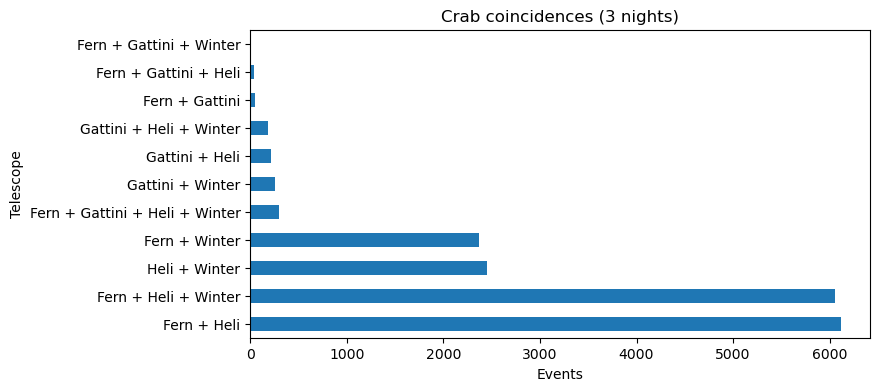

Telescope
Fern + Heli                       6113
Fern + Heli + Winter              6059
Heli + Winter                     2457
Fern + Winter                     2366
Fern + Gattini + Heli + Winter     298
Gattini + Winter                   256
Gattini + Heli                     217
Gattini + Heli + Winter            185
Fern + Gattini                      53
Fern + Gattini + Heli               39
Fern + Gattini + Winter             11
Name: count, dtype: int64

In [8]:
# events per telescope combination
combos = df.groupby("Event").Telescope.agg(lambda t: " + ".join(sorted(t))).value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
combos.plot.barh(ax=ax)
ax.set_xlabel("Events")
ax.set_title(f"{SOURCE} coincidences ({df.Date.nunique()} nights)")
plt.show()
combos

## Cleaning data

/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


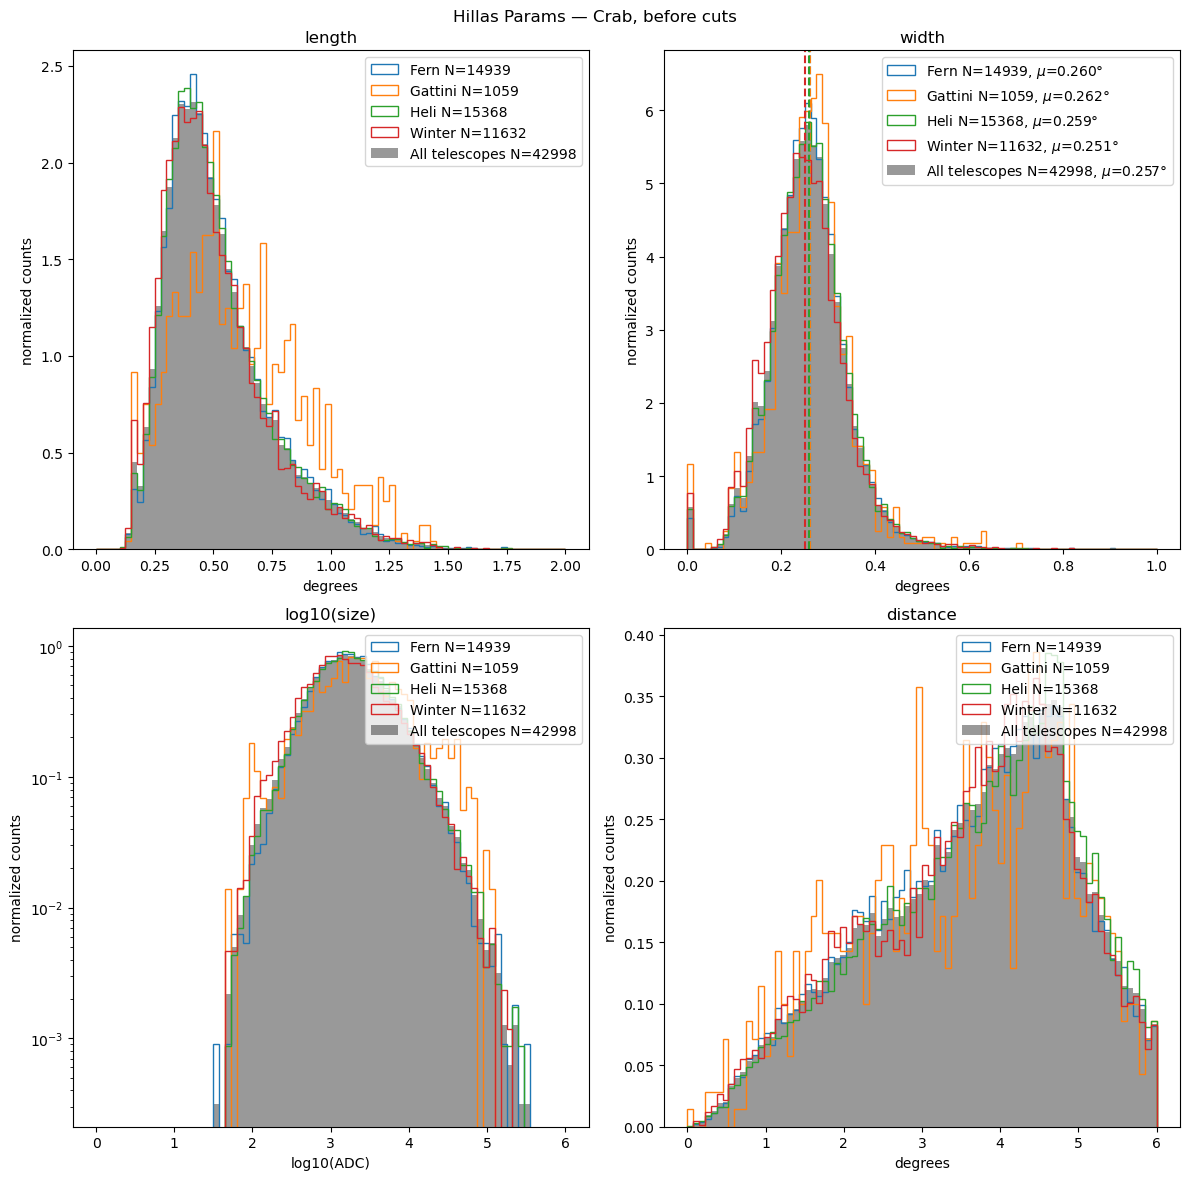

In [9]:
# image parameters before cuts
ev.plot_hillas(df, f"Hillas Params — {SOURCE}, before cuts", colors=COLORS)
plt.show()

In [10]:
array = ev.apply_cuts(df, min_tel=MIN_TEL, min_npix=MIN_NPIX, telescopes=TELESCOPES, cuts=IMAGE_CUTS)
array.head()

,Event,Date,Run,ImageIndex,Telescope,Timestamp,FlipSide,MeanX,MeanY,Phi,Size,Npix,Length,Width,Miss,Distance,Alpha
0,0,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,0,Fern,1.789639e+09,preflip,-3.528994,3.916070,132.257750,1971.785771,20,0.402934,0.267899,0.021523,5.271565,0.233932
1,0,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,4,Heli,1.789639e+09,preflip,-3.069369,3.771221,150.508106,1768.235877,17,0.412835,0.211457,1.771515,4.862420,21.366218
2,0,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,2,Winter,1.789639e+09,preflip,-2.727868,3.217626,72.814986,1678.773674,14,0.309336,0.236620,3.556758,4.218338,57.475928
3,1,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,1,Fern,1.789639e+09,preflip,-1.304504,-4.288824,282.314280,1422.925868,18,0.564889,0.211591,2.189185,4.482828,29.232134
5,1,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,3,Winter,1.789639e+09,preflip,-0.556744,-4.268275,274.381155,968.079840,16,0.449974,0.273737,0.881175,4.304432,11.812724


In [11]:
array.describe()

,Event,ImageIndex,Timestamp,MeanX,MeanY,Phi,Size,Npix,Length,Width,Miss,Distance,Alpha
count,30617.000000,30617.000000,3.061700e+04,30617.000000,30617.000000,30617.000000,30617.000000,30617.000000,30617.000000,30617.000000,30617.000000,30617.000000,30617.000000
mean,8599.146324,5807.404057,1.789814e+09,0.115575,-0.095617,180.467806,2075.362301,18.669105,0.468181,0.224836,2.388525,3.748823,44.184288
std,5278.346404,3886.421608,1.894446e+05,2.790121,2.848298,104.584630,2797.378336,11.094845,0.194885,0.049941,1.547715,1.365996,26.046338
min,0.000000,0.000000,1.789639e+09,-4.780478,-4.784950,0.003361,77.067131,3.000000,0.124425,0.044809,0.000062,0.017096,0.004867
25%,4012.000000,2401.000000,1.789645e+09,-2.240148,-2.626362,88.584965,701.891942,11.000000,0.331424,0.192912,1.031609,2.767216,21.346287
50%,8409.000000,5433.000000,1.789731e+09,0.275173,-0.270340,182.015235,1272.566998,16.000000,0.423252,0.232555,2.234666,3.944827,44.492043
75%,13120.000000,8831.000000,1.790075e+09,2.504242,2.379551,270.509896,2369.877197,24.000000,0.560179,0.264680,3.654048,4.749954,66.300421
max,18053.000000,16821.000000,1.790079e+09,4.788679,4.776665,359.988786,77776.130214,93.000000,2.076431,0.307619,6.631100,6.658208,89.998563


In [12]:
array.Event.nunique()

16418

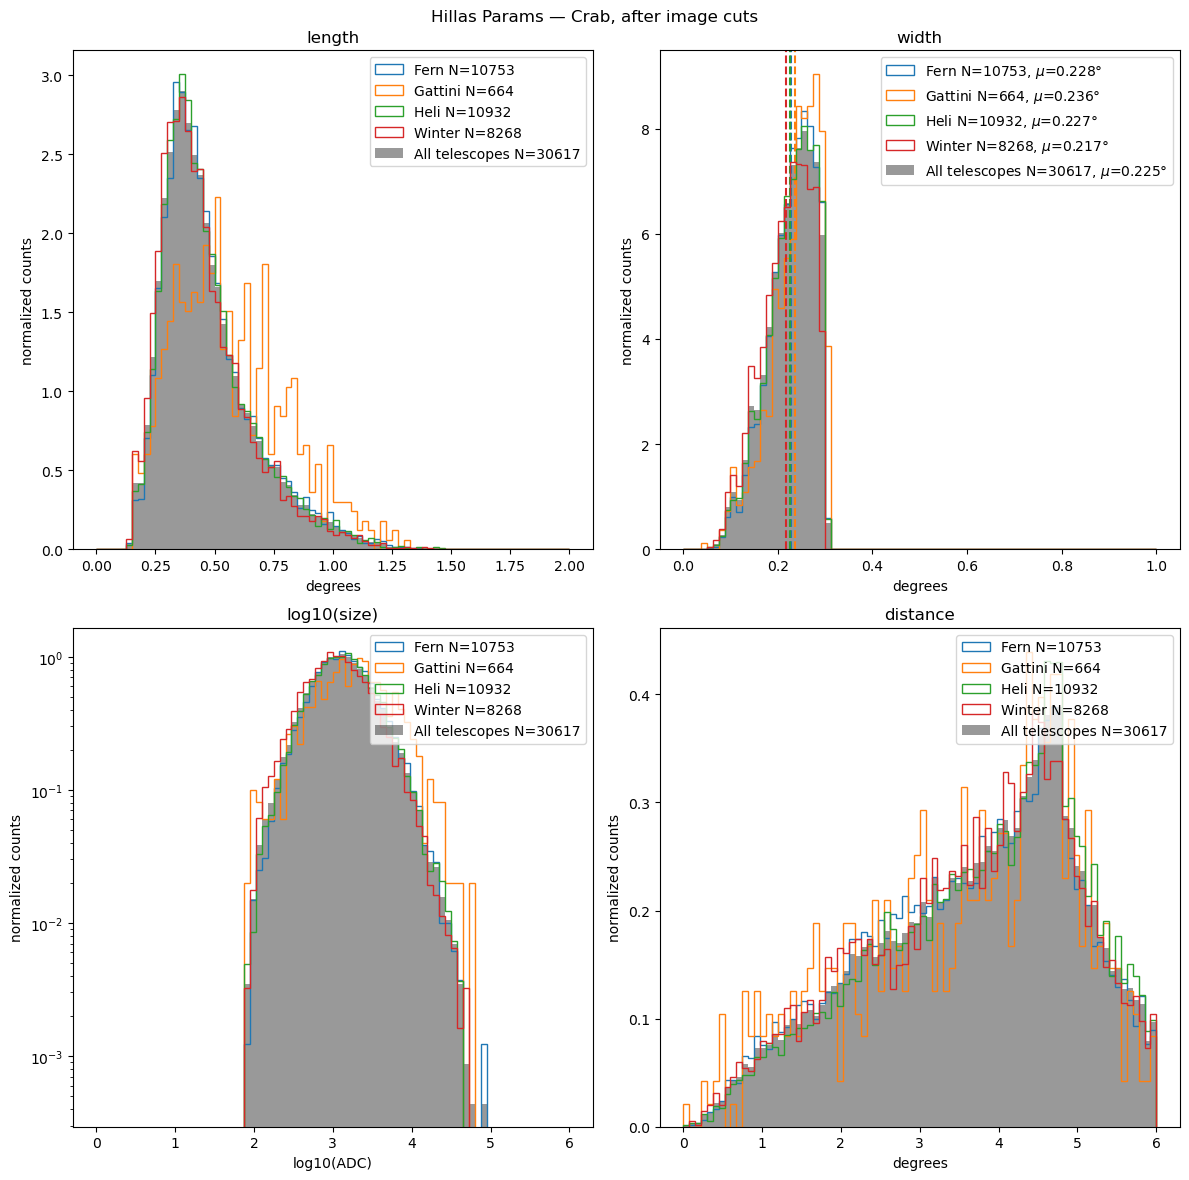

In [13]:
# image parameters after image cuts
ev.plot_hillas(array, f"Hillas Params — {SOURCE}, after image cuts", colors=COLORS)
plt.show()

# Arrival Directions

In [14]:
directions = reconstruct_directions(array)
directions.describe()

,Event,Xoffset,Yoffset
count,11882.000000,11882.000000,11882.000000
mean,8609.359704,0.184534,-0.147416
std,5258.748002,33.125177,15.996493
min,0.000000,-1373.725746,-1444.879477
25%,4161.250000,-2.349082,-2.693755
50%,8368.500000,0.229939,-0.195759
75%,13054.500000,2.649385,2.492898
max,18053.000000,2784.085829,594.513986


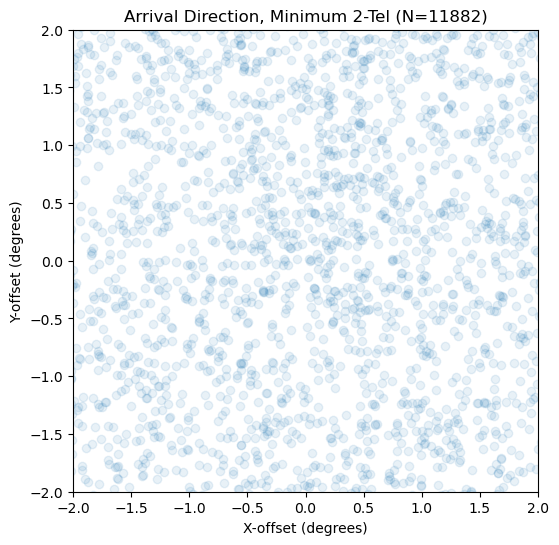

In [15]:
fig,axs = plt.subplots(figsize=(6,6))
plt.xlabel('X-offset (degrees)')
plt.ylabel('Y-offset (degrees)')
axs.set(xlim=[-PLOT_RADIUS,PLOT_RADIUS],ylim=[-PLOT_RADIUS,PLOT_RADIUS],title='Arrival Direction, Minimum {:.0f}-Tel (N={:.0f})'.format(MIN_TEL,len(directions)))
axs.scatter(directions.Xoffset,directions.Yoffset,alpha=0.1)

### Convert to RA/DEC

In [16]:
# pointing: each run's own (REFERENCE's mount while tracking), since wobble offsets differ run to run,
# replaced by POINTING_OVERRIDES for runs whose hk is missing or wrong
pointings = {}
for date in directions.Date.unique():
    pointings |= ev.run_pointings(ev.source_runs(RAW_DATA_DIR / date, REFERENCE, SOURCE), REFERENCE)
unknown = sorted(set(POINTING_OVERRIDES) - set(directions.Run))
if unknown:
    raise ValueError(f"pointing_overrides for runs with no {SOURCE} events (check the run folder names): {unknown}")
pointings |= POINTING_OVERRIDES
missing = sorted(set(directions.Run) - set(pointings))
if missing:
    print(f"no hk pointing for runs {missing}, dropping them")
    directions = directions[directions.Run.isin(pointings)].copy()
pointings = {run: pointings[run] for run in directions.Run.unique()}
display(pd.DataFrame([(run, c.ra.deg, c.dec.deg, c.separation(SOURCE_POSITION).deg if SOURCE_POSITION is not None else np.nan)
              for run, c in pointings.items()], columns=["Run", "RA", "DEC", "offset from source"]))

# map center: the source, else the median run pointing
if SOURCE_POSITION is not None:
    center = SOURCE_POSITION
else:
    center = SkyCoord(np.median([c.ra.deg for c in pointings.values()]), np.median([c.dec.deg for c in pointings.values()]), unit=u.deg)

w = sg.make_wcs(center)
directions['RA'],directions['DEC'] = sg.camera_to_sky(directions, pointings)

,Run,RA,DEC,offset from source
0,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,83.636205,22.517130,0.499753
1,obs_Palomar.start_2026-09-17T11:08:55Z.runtype...,83.635875,22.517129,0.499750
2,obs_Palomar.start_2026-09-18T10:53:14Z.runtype...,83.640345,21.517119,0.500324
3,obs_Palomar.start_2026-09-22T10:36:38Z.runtype...,83.636205,22.517122,0.499745


In [17]:
w

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : np.float64(83.63241666666664) np.float64(22.01738888888889) 
CRPIX : np.float64(0.0) np.float64(0.0) 
PC1_1 PC1_2  : np.float64(1.0) np.float64(0.0) 
PC2_1 PC2_2  : np.float64(0.0) np.float64(1.0) 
CDELT : np.float64(-1.0) np.float64(1.0) 
NAXIS : 0  0

In [18]:
directions.describe()

,Event,Xoffset,Yoffset,RA,DEC
count,11882.000000,11882.000000,11882.000000,11882.000000,11882.000000
mean,8609.359704,0.184534,-0.147416,83.517876,22.046112
std,5258.748002,33.125177,15.996493,6.798764,4.243834
min,0.000000,-1373.725746,-1444.879477,5.831308,-50.010613
25%,4161.250000,-2.349082,-2.693755,80.782205,19.489016
50%,8368.500000,0.229939,-0.195759,83.394156,22.000372
75%,13054.500000,2.649385,2.492898,86.166094,24.684198
max,18053.000000,2784.085829,594.513986,356.175818,74.526244


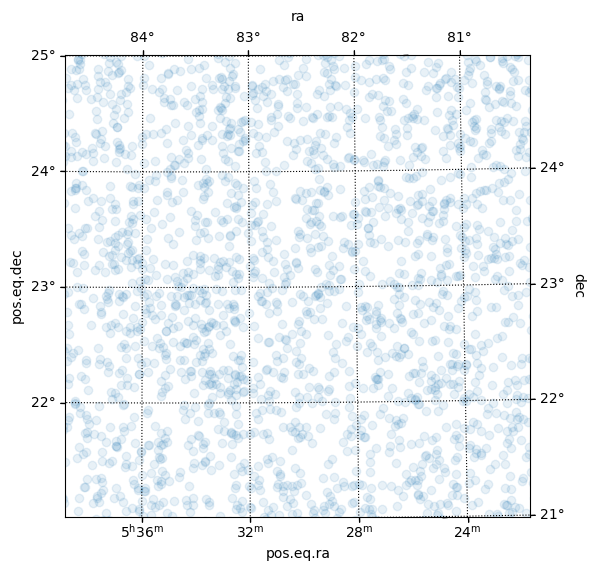

In [19]:
fig=plt.figure(figsize=(6,6))
ax = plt.subplot(projection=w)
ax.set_xlim(-PLOT_RADIUS,PLOT_RADIUS)
ax.set_ylim(-PLOT_RADIUS,PLOT_RADIUS)
ax.scatter(directions.RA,directions.DEC,transform=ax.get_transform('icrs'),alpha=0.1)

overlay = ax.get_coords_overlay('icrs')
overlay.grid(color='black', ls='dotted')

## Event display
Run the cell below again for a different set of random images.

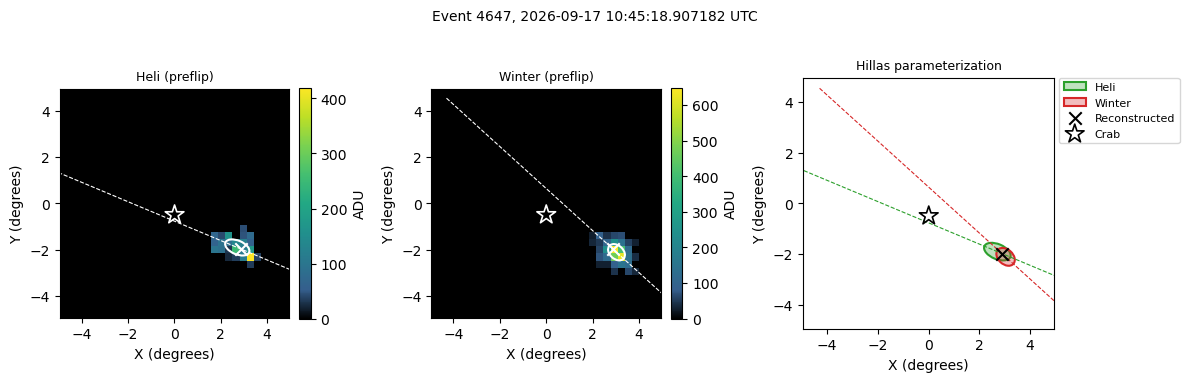

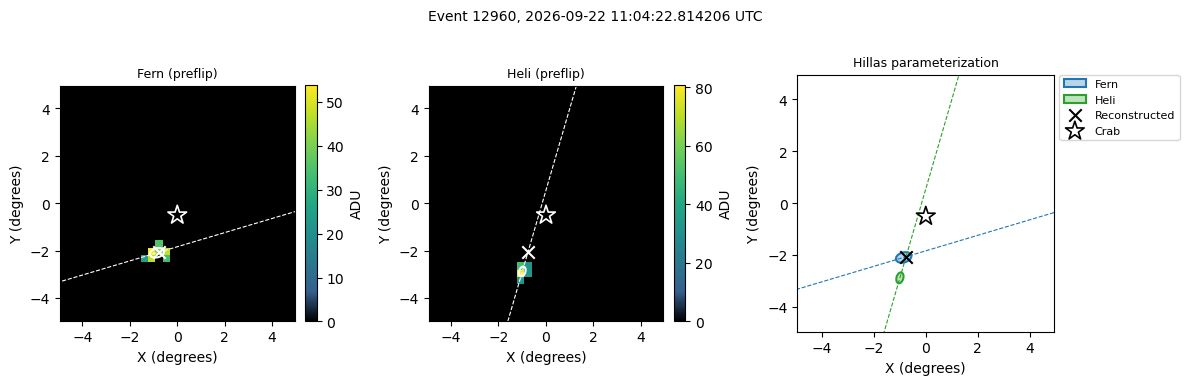

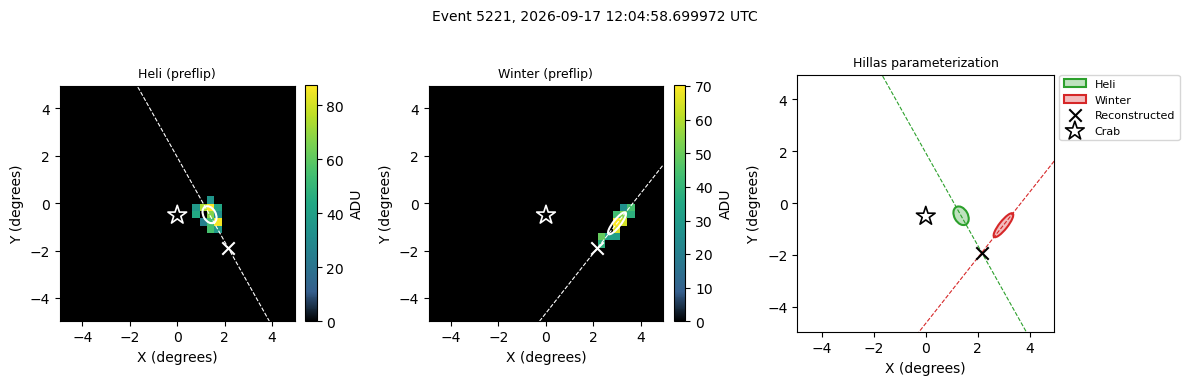

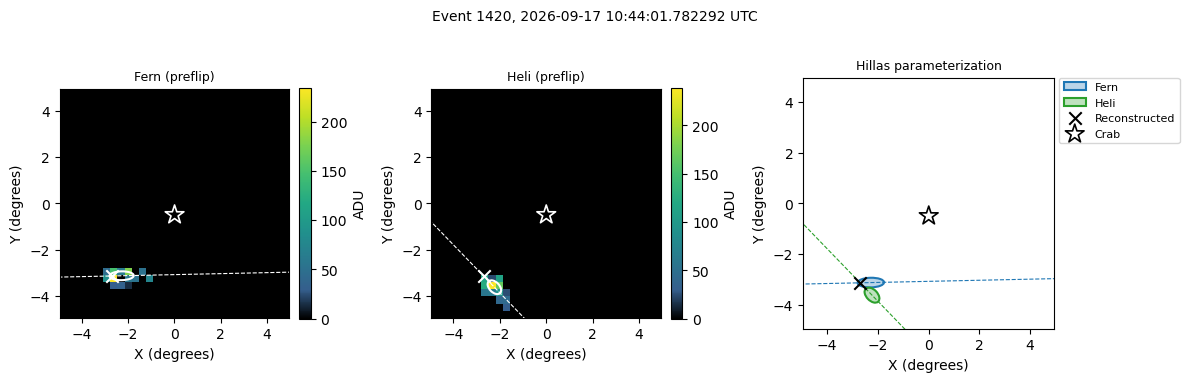

In [36]:
N_EVENTS = 4 # events to display, each with one panel per telescope image
for e in np.random.default_rng().choice(directions.Event, size=min(N_EVENTS, len(directions)), replace=False):
    ev.plot_event(
        array[array.Event == e], directions[directions.Event == e].iloc[0], OUTPUT_DIR, SOURCE,
        source_position=SOURCE_POSITION, pointings=pointings, colors=COLORS,
        rotate_postflip=ROTATE_POSTFLIP, pointing_corrections=POINTING_CORRECTIONS,
    )
    plt.show()

# Counts Map

In [21]:
n_bins = int(2*PLOT_RADIUS / BIN_WIDTH)
bins_RA = np.linspace(center.ra.deg-PLOT_RADIUS, center.ra.deg+PLOT_RADIUS, n_bins)
bins_DEC = np.linspace(center.dec.deg-PLOT_RADIUS, center.dec.deg+PLOT_RADIUS, n_bins)

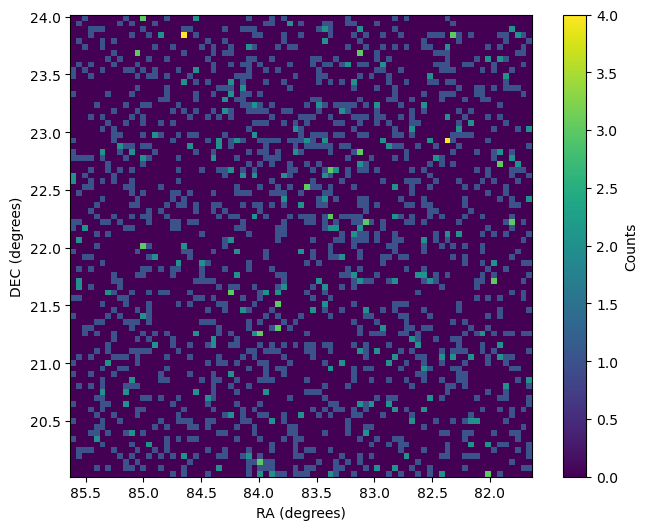

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))

hist = ax.hist2d(directions.RA, directions.DEC, bins=[bins_RA, bins_DEC], cmap='viridis')

ax.invert_xaxis()
ax.set_aspect('equal')
ax.set_xlabel('RA (degrees)')
ax.set_ylabel('DEC (degrees)')

cbar = fig.colorbar(hist[3], ax=ax, label='Counts')

plt.show()

## Define On/Off Regions

In [23]:
# test position defaults to the source (SOURCE_POSITION), else the median pointing
on_region = (center.ra.deg, center.dec.deg)
# on_region = (SOURCES["HAWC J0543+233"].ra.deg, SOURCES["HAWC J0543+233"].dec.deg) # or any other heap.sources entry

counter = sg.OnOffCounter(directions, array, pointings, THETA, MAX_DISTANCE, off_method=OFF_REGIONS, position_cuts=POSITION_CUTS)
off_regions = counter.off_region_centers(*on_region) # every night's, in RA/DEC

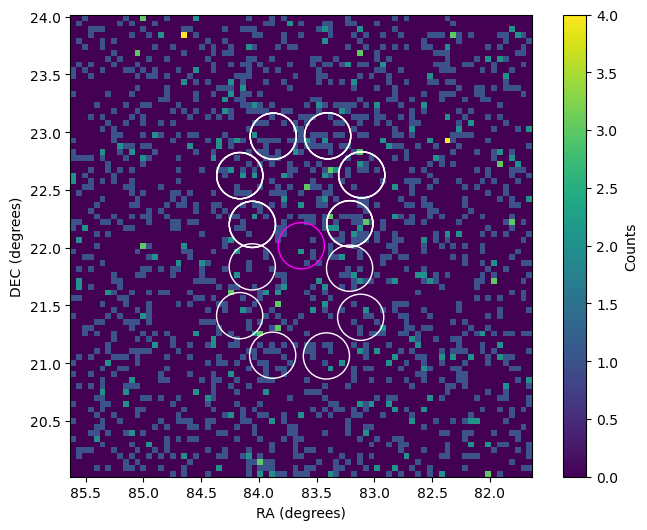

Number of off regions (all nights):  24


In [24]:
fig, ax = plt.subplots(figsize=(8, 6))

hist = ax.hist2d(directions.RA, directions.DEC, bins=[bins_RA, bins_DEC], cmap='viridis')

ax.invert_xaxis()
ax.set_aspect('equal')
ax.set_xlabel('RA (degrees)')
ax.set_ylabel('DEC (degrees)')

cbar = fig.colorbar(hist[3], ax=ax, label='Counts')

for region in off_regions:
    circ = Circle(region, THETA, facecolor='None', edgecolor='white', lw=1)
    ax.add_patch(circ)
ax.add_patch(Circle(on_region,THETA,facecolor='None',edgecolor='magenta', lw=1))

plt.show()
print('Number of off regions (all nights): ',len(off_regions))

# Significance

Li and Ma (9):
$S=\frac{N_{on}-\alpha N_{off}}{\sqrt{\alpha(N_{on}+N_{off})}}$

`heap.significance.significance()` uses Equation 17

In [25]:
on, off = counter.events(*on_region)
N_on, N_off, alpha = counter.count(*on_region)
print(f"N_on = {N_on}, N_off = {N_off}, alpha = {alpha:.4f}")

# at test position only
sg.significance(N_on,N_off,alpha)

N_on = 11, N_off = 86, alpha = 0.1667


np.float64(-0.8552434372835341)

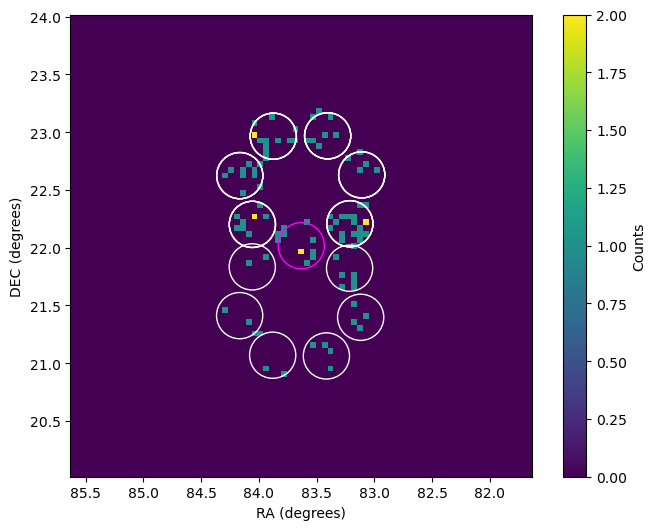

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))
onoff=pd.concat([on,off])

hist = ax.hist2d(onoff.RA, onoff.DEC, bins=[bins_RA, bins_DEC], cmap='viridis')

ax.invert_xaxis()
ax.set_aspect('equal')
ax.set_xlabel('RA (degrees)')
ax.set_ylabel('DEC (degrees)')

cbar = fig.colorbar(hist[3], ax=ax, label='Counts')

circ1 = Circle(on_region, THETA, facecolor='None', edgecolor='magenta', lw=1)
ax.add_patch(circ1)

for region in off_regions:
    circ = Circle((region[0],region[1]), THETA, facecolor='None', edgecolor='white', lw=1)
    ax.add_patch(circ)

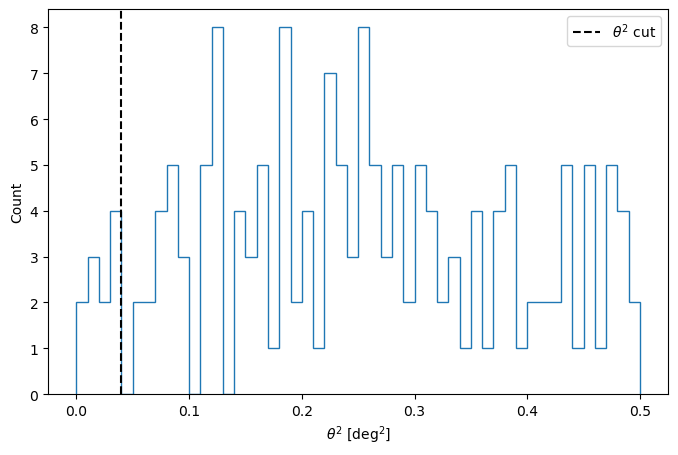

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))

theta2 = counter.theta_square(*on_region).set_index('Event') # in each night's camera frame
directions['ThetaSquare'] = directions.Event.map(theta2.ThetaSquare)
directions['Distance'] = directions.Event.map(theta2.Distance)

directions_dcut = directions.dropna(subset=['Distance']) if MAX_DISTANCE is None else directions[directions.Distance < MAX_DISTANCE]

ax.hist(directions_dcut.ThetaSquare, bins=50, range=(0, 0.5), histtype='step')
ax.axvline(THETA**2, color='k', linestyle='--', label=r'$\theta^2$ cut')
ax.set_xlabel(r'$\theta^2$ [deg$^2$]')
ax.set_ylabel('Count')
ax.legend()
plt.show()

## Significance map

In [28]:
sig = sg.calc_sigmap(counter, bins_RA, bins_DEC, BIN_WIDTH)

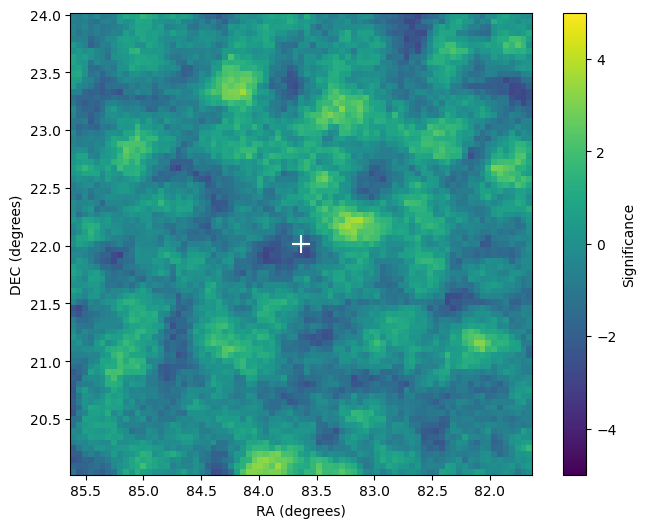

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))
sg.plot_sky_map(ax, sig, sig.significance, 'Significance', bins_RA, bins_DEC, on_region, vmin=CBAR_VMIN, vmax=CBAR_VMAX)
plt.show()

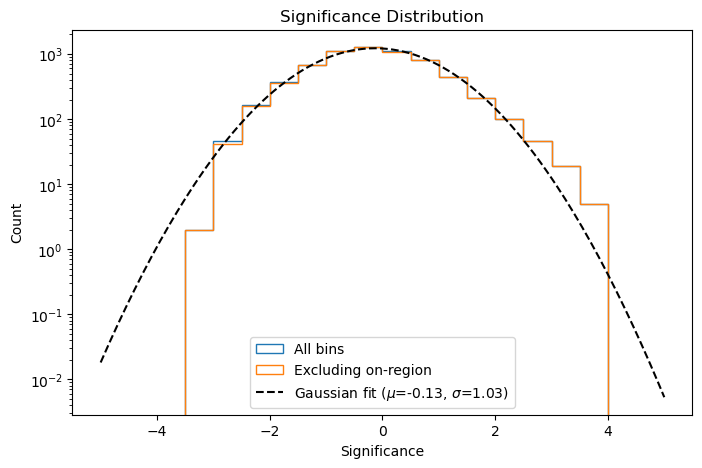

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))

nbins=20
bins = np.linspace(CBAR_VMIN, CBAR_VMAX,nbins+1)

on_mask = np.hypot(sig.testPosX - on_region[0], sig.testPosY - on_region[1]) < THETA
sig_excl = sig[~on_mask]

ax.hist(sig.significance, bins=bins, histtype='step', label='All bins')
ax.hist(sig_excl.significance, bins=bins, histtype='step', label='Excluding on-region')

mu, std = norm.fit(sig_excl.significance)
x = np.linspace(CBAR_VMIN, CBAR_VMAX, 200)
bin_width = bins[1] - bins[0]
p = norm.pdf(x, mu, std) * len(sig_excl.significance) * bin_width
ax.plot(x, p, 'k--', label=f'Gaussian fit ($\\mu$={mu:.2f}, $\\sigma$={std:.2f})')

ax.set_yscale('log')
ax.set_xlabel('Significance')
ax.set_ylabel('Count')
ax.set_title('Significance Distribution')
ax.legend()

plt.show()

# On, Off, Alpha, and Excess Maps

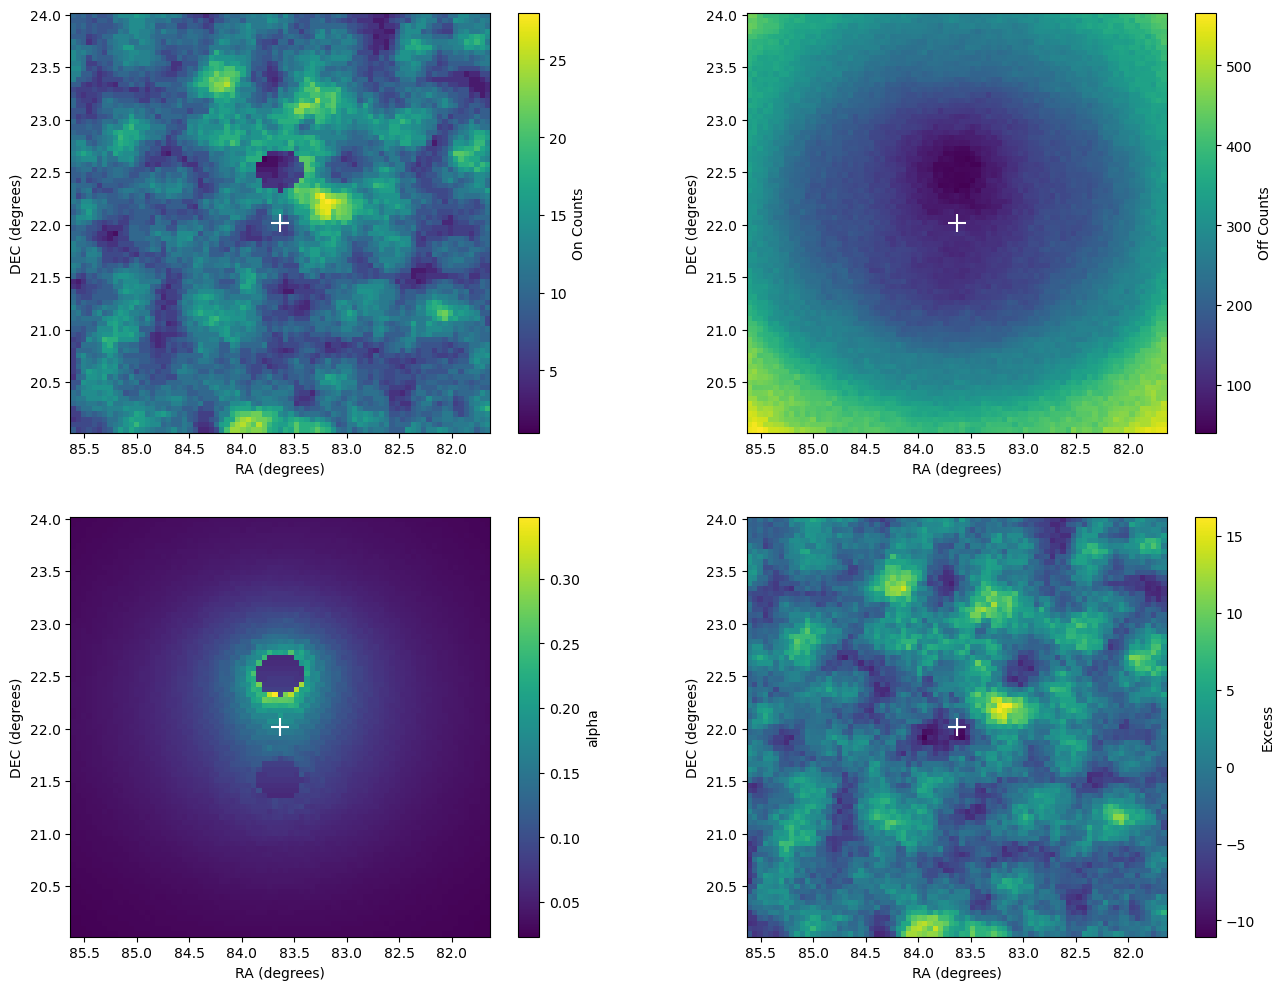

In [31]:
excess=sig.on-sig.alpha*sig.off

fig, axs = plt.subplots(2, 2, figsize=(16, 12))
for ax, (weights, label) in zip(axs.flat, [(sig.on, 'On Counts'), (sig.off, 'Off Counts'), (sig.alpha, 'alpha'), (excess, 'Excess')]):
    sg.plot_sky_map(ax, sig, weights, label, bins_RA, bins_DEC, on_region)
plt.show()

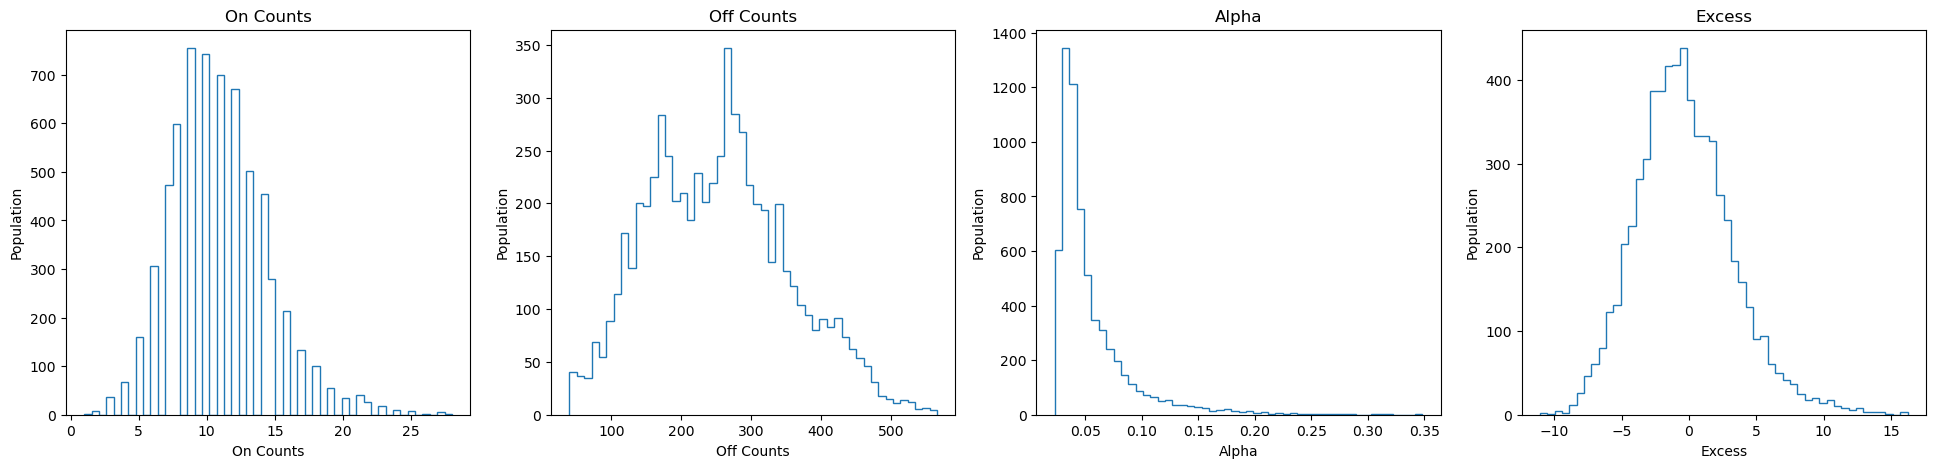

In [32]:
# other distributions
fig, axs = plt.subplots(1,4,figsize=(24, 5))
for ax, (values, title) in zip(axs, [(sig.on, 'On Counts'), (sig.off, 'Off Counts'), (sig.alpha, 'Alpha'), (excess, 'Excess')]):
    ax.hist(np.round(values, 10), bins=50, histtype='step') # rounding: alpha can differ only in the last bit, which np.histogram can't bin
    ax.set_title(title)
    ax.set_xlabel(title)
    ax.set_ylabel('Population')

plt.show()

# Per night
On/off counts and alpha at the test position for each night, and significance accumulated night by night.

In [33]:
nights = counter.per_date(*on_region)
nights.insert(1, "Events", nights.Date.map(directions.Date.value_counts()))
nights["excess"] = nights.on - nights.alpha*nights.off
nights["significance"] = [sg.significance(n_on, n_off, a) for n_on, n_off, a in zip(nights.on, nights.off, nights.alpha)]
nights["cumulative significance"] = [sg.significance(*sg.combine_on_off(nights.iloc[:i+1])) for i in range(len(nights))]
nights

,Date,Events,on,off,alpha,excess,significance,cumulative significance
0,20260917,4447,2,31,0.166667,-3.166667,-1.500426,-1.500426
1,20260918,3532,4,22,0.166667,0.333333,0.158474,-0.945268
2,20260922,3903,5,33,0.166667,-0.500000,-0.200939,-0.855243


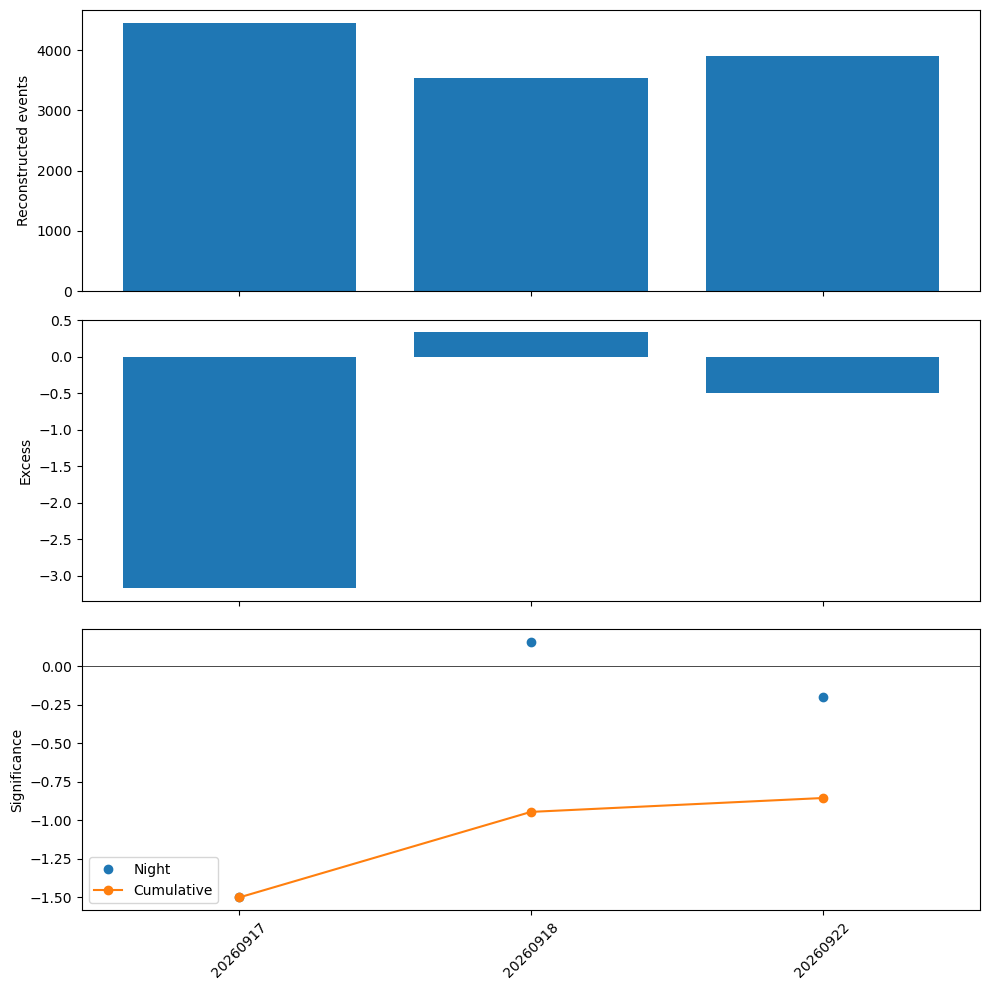

In [34]:
fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
axs[0].bar(nights.Date, nights.Events)
axs[0].set_ylabel("Reconstructed events")
axs[1].bar(nights.Date, nights.excess)
axs[1].set_ylabel("Excess")
axs[2].plot(nights.Date, nights.significance, "o", label="Night")
axs[2].plot(nights.Date, nights["cumulative significance"], "-o", label="Cumulative")
axs[2].axhline(0, color="k", lw=0.5)
axs[2].set_ylabel("Significance")
axs[2].legend()
axs[2].tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()